### This notebook compares performance of mechanistic parameter inference for a noisily- and partially-observed Lorenz '63 SDE system. It uses three different approaches for coping with the presence of un-observed latent states:
1. "filter": A non-linear filtering-based approach that *marginalizes out the latent states* under each proposed set of mechanistic parameters. 
    - MAP-estimation is performed using the ADAM optimizer (implemented via NumPyro's SVI functionality).
    - Crucially, the MAP-estimation is only over the mechanistic parameters, not the latent states (which are marginalized out via the non-linear filter, conditioned on the proposed mechanistic parameters).
2. "Eulmar": An explicit representation of the latent states using Euler-Maruyama discretization. 
    - MAP-estimation is performed using the ADAM optimizer (implemented via NumPyro's SVI functionality).
    - Here, the MAP-estimation is over both the mechanistic parameters and the latent states (represented explicitly via Euler-Maruyama discretization).
3. "Diffrax": Another explicit representation of the latent states, this time using fewer latent states that are interpolated to form a Virtual Brownian Tree in Diffrax.
    - Think of this as a lower-dimensional representation of the latent brownian increments, where the latent states are represented at a coarser time resolution and interpolated in between.
    - MAP-estimation is performed using the ADAM optimizer (implemented via NumPyro's SVI functionality).
    - Here, the MAP-estimation is over both the mechanistic parameters and the latent states (fewer than in the Euler-Maruyama case).

## Findings
- Filter-based and Eulmar-based approaches are able to support accurate inference of the mechanistic parameters of the Lorenz '63 SDE from noisy and partial observations of the latent states for short, medium, and long observation durations (T=2, T=10, T=100, T=1000).
- Diffrax-based approach also supported accurate inference of parameters in shorter observation durations (T=2, T=10). 
    - We did not run it on longer trajectories --- it fails there because its number of latent states needs to be increased; we did not set up this functionality.

- Filter-based and Eulmar-based approaches had similar wall-clock time performance for short-to-medium observation durations (T=2, T=10). 
- For longer observation durations (T=100, T=1000), the filter-based approach was significantly slower than the Eulmar-based approach.
    - This is likely due to the parallelization that occurs in jointly inferring all states in the Eulmar-based approach, whereas the filter-based approach must sequentially process observations.
    - In long-time settings, "chunking" the time-series into smaller segments and applying the filter to each chunk may help speed up inference.

- Should we NEVER use filter-based approaches then?
    - Explicit representation (and inference) of latent states via Euler-Maruyama discretization appears most effective when the system is known up to a few parameters.
    - We show in another notebook that when we perform the same experiment (but learn a neural-drift), that the filter-based approach is much more efficient (and, in fact, the only feasible approach).

In [1]:
import os
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, init_to_value, init_to_median, Predictive
from numpyro.infer import MCMC, NUTS
from numpyro.infer.autoguide import AutoDelta, AutoDiagonalNormal
import jax.random as jr

# everything from your own package
from cd_dynamax import (
    ContDiscreteNonlinearGaussianSSM,
    adjust_rhs,
    make_optimizer,
    make_key_sequence,
)

from cd_dynamax.src.utils.demo_utils import (
    build_exponents,
    poly_drift,
    get_or_sample,
    sample_t_emissions,
    plot_traj_kde,
    plot_simulated_data,
    plot_coeff_heatmaps,
    plot_param_recovery,
    plot_loss_curve
)

import diffrax as dfx


/opt/homebrew/Caskroom/miniconda/base/envs/cd_dynamax-2025-2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------------------------
# Helper functions
# ---------------------------
def get_or_sample(name, d, value):
    return numpyro.sample(name, d) if value is None else numpyro.deterministic(name, value)

def _lorenz63_drift(x, sigma, rho, beta):
    dx = sigma * (x[1] - x[0])
    dy = x[0] * (rho - x[2]) - x[1]
    dz = x[0] * x[1] - beta * x[2]
    return jnp.stack([dx, dy, dz])

def _observe_mvn(y_mean, emission_covariance, emissions):
    y = numpyro.sample(
        "y",
        dist.MultivariateNormal(loc=y_mean, covariance_matrix=emission_covariance),
        obs=emissions,
    )  # y_mean shape (T, p) => batch=T, event=p
    numpyro.deterministic("emissions", y)
    return y

# Build filter hyperparameters
filter_kwargs = {
    "filter_type": 'EKF',
    "filter_state_order": 'zeroth',
    # "enkf_N_particles": 25,
    "diffeqsolve_max_steps": 100,
}

# Diffeqsolve settings
diffeqsolve_kwargs = dict(
    solver=dfx.Euler(),
    dt0=1e-2,
    stepsize_controller=dfx.ConstantStepSize()
)


In [3]:
# ---------------------------
# Numpyro Meta-model (has 3 modes for computing likelihood)
# MODE = "diffrax"  # "filter" | "eulmar" | "diffrax"
# ---------------------------
def model(
    t_emissions,
    emissions=None,

    # --- shared params ---
    state_dim=3,
    emission_dim=3,
    initial_mean=None,
    sigma=None,
    rho=None,
    beta=None,
    diffusion_coeff=None,     # diagonal diffusion (R^{state_dim})
    H=None,                   # (emission_dim, state_dim)
    emission_covariance=None, # NEW: (emission_dim, emission_dim), defaults to I
    initial_cov=None,      # NEW: (state_dim, state_dim), defaults to I

    # --- mode selection ---
    mode="filter",            # "filter" | "eulmar" | "diffrax"
):
    
    # Build the overall CD-SDE class    
    cdnlgssm = ContDiscreteNonlinearGaussianSSM(state_dim=state_dim, emission_dim=emission_dim)

    t = jnp.asarray(t_emissions).reshape(-1)
    T = t.shape[0]

    # Shared params
    initial_mean    = get_or_sample("initial_mean",
                        dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim)),
                        initial_mean)
    sigma           = get_or_sample("sigma", dist.LogNormal(0.0, 5.0), sigma)
    rho             = get_or_sample("rho", dist.LogNormal(jnp.log(28.0), 0.2), rho)
    beta            = get_or_sample("beta", dist.LogNormal(jnp.log(8.0/3.0), 0.2), beta)
    diffusion_coeff = get_or_sample("diffusion_coeff",
                        dist.LogNormal(0.0, 1.0).expand((state_dim,)), diffusion_coeff)
    H               = get_or_sample("H",
                        dist.Uniform(-2.0, 2.0).expand((emission_dim, state_dim)), H)
    emission_covariance = get_or_sample("emission_covariance",
                                        dist.Uniform(0.1, 2.0).expand((emission_dim,)).to_event(1),
                                        emission_covariance) # Diagonal covariance. Not tested...assuming known.
    initial_cov    = get_or_sample("initial_cov",
                                   dist.Uniform(0.5, 2.0).expand((state_dim,)).to_event(1),
                                   initial_cov)  # Diagonal covariance. Not tested...assuming known.

    # ============== FILTER mode (marginal likelihood) ==============
    if mode == "filter":

        def f_l63(x):
            return _lorenz63_drift(x, sigma, rho, beta)

        params = cdnlgssm.build_params(
            initial_mean=initial_mean,
            initial_cov=initial_cov,
            drift=f_l63,
            diffusion_coeff=diffusion_coeff,
            diffusion_cov=jnp.eye(state_dim),
            emission_function=lambda x: H @ x,
            emission_cov=emission_covariance,  # <- pass through if your build_params supports it
        )

        if emissions is None:
            states, emissions = cdnlgssm.sample(
                params=params,
                num_timesteps=T,
                key=numpyro.prng_key(),
                t_emissions=t_emissions,
                transition_type="path"
            )
            numpyro.deterministic("states", states)
            numpyro.deterministic("emissions", emissions)

        filtered = cdnlgssm.filter(
                params=params,
                emissions=emissions,
                t_emissions=t_emissions,
                warn=False,
                **filter_kwargs,
            )
        numpyro.factor("log_likelihood", filtered.marginal_loglik)
        numpyro.deterministic("neg_log_likelihood", -filtered.marginal_loglik)
        return

    # ============== EULMAR mode (NumPyro Euler–Maruyama) ==============
    if mode == "eulmar":
        assert initial_mean.shape == (state_dim,)
        assert initial_cov.shape == (state_dim, state_dim)
        assert H.shape == (emission_dim, state_dim)
        
        def sde_fn(x, ti):
            drift = _lorenz63_drift(x, sigma, rho, beta)
            diff = jnp.diag(diffusion_coeff) if diffusion_coeff.ndim == 2 else diffusion_coeff  # returns (3,) from a (3,3) input
            return drift, diff

        # drift: R^{state_dim} -> R^{state_dim}
        # diffusion: R^{state_dim} -> R^{state_dim, state_dim}
        x_path = numpyro.sample(
            "x_path",
            dist.EulerMaruyama(
                t=t,
                sde_fn=sde_fn,
                init_dist=dist.MultivariateNormal(initial_mean, initial_cov),
            ),
        )  # (T, state_dim)

        y_mean = x_path @ H.T
        _observe_mvn(y_mean, emission_covariance, emissions)
        numpyro.deterministic("states", x_path)
        return

    # ============== DIFFRAX mode (fixed Brownian path) ==============
    if mode == "diffrax":
        if T == 1:
            # No time interval; treat as degenerate "solve"
            x_path = initial_mean[None, :]
            y_mean = x_path @ H.T
            _observe_mvn(y_mean, emission_covariance, emissions)
            numpyro.deterministic("states", x_path)
            return

        if diffeqsolve_kwargs['dt0'] is None:
            diffeqsolve_kwargs['dt0']  = jnp.minimum((t[1:] - t[:-1]).min(), 1.0)

        # Reparameterized Brownian increments (T-1, state_dim)
        dts = t[1:] - t[:-1]
        sqrt_dts = jnp.sqrt(dts)
        z = numpyro.sample("bm_increments",
                           dist.Normal(0.0, 1.0).expand((T-1, state_dim)))
        dW = z * sqrt_dts[:, None]
        W_knots = jnp.concatenate([jnp.zeros((1, state_dim)),
                                   jnp.cumsum(dW, axis=0)], axis=0)

        bm = dfx.LinearInterpolation(ts=t, ys=W_knots)

        def drift(ti, x, args):
            return _lorenz63_drift(x, sigma, rho, beta)

        def diffusion(ti, x, args):
            diff = jnp.diag(diffusion_coeff) if diffusion_coeff.ndim == 2 else diffusion_coeff  # returns (3,) from a (3,3) input
            return diff

        term = dfx.MultiTerm(
            dfx.ODETerm(drift),
            dfx.ControlTerm(diffusion, bm),
        )

        x0 = numpyro.sample("x0", dist.MultivariateNormal(initial_mean, initial_cov))
        sol = dfx.diffeqsolve(
            term,
            t0=t[0], t1=t[-1],
            y0=x0, args=None,
            saveat=dfx.SaveAt(ts=t),
            **diffeqsolve_kwargs,
        )
        x_path = sol.ys                       # (T, state_dim)
        y_mean = x_path @ H.T                 # (T, emission_dim)

        _observe_mvn(y_mean, emission_covariance, emissions)
        numpyro.deterministic("states", x_path)
        return

    raise ValueError(f"Unknown mode={mode}")



In [4]:
# Do a mode-based experiment
# In each case, generate data according to the same "mode"
# MODE:
# --- diffrax: generate data using same solver AND brownian Tree used in inference
# --- EulMar: generate data using same solver used in inference
# --- filter: generate data using Heun SDE solver (and compute log-like using Ensemble Kalman Filter)

# ------------------------
# Generate synthetic data
# ------------------------

from time import time
def run_experiment(state_dim=3, emission_dim=3, t_emissions=None, mode='filter', do_mcmc=False, num_svi_steps=1000, learning_rate=1e-2):
    print(f"\n #### Running experiment in **{mode}** mode ####")
    true_values = {
        "state_dim": state_dim,
        "emission_dim": emission_dim,
        "initial_mean": jnp.zeros(state_dim),
        "sigma": 10.0,
        "rho": 28.0,
        "beta": 8.0 / 3.0,
        "diffusion_coeff": 1 * jnp.eye(3),
        "H": jnp.eye(emission_dim, state_dim),
        "emission_covariance": jnp.eye(emission_dim),
        "initial_cov": jnp.eye(state_dim),
    }
    
    results = {'true_values': true_values}

    known_param_names = ["diffusion_coeff", "H", "initial_mean", "emission_dim", "state_dim", "emission_covariance", "initial_cov"]
    known_values = {k: true_values[k] for k in known_param_names}

    learned_param_names = [pname for pname in true_values.keys() if pname not in known_param_names]
    
    sim_data = Predictive(model, num_samples=1)(
        jr.PRNGKey(0), t_emissions=t_emissions, mode=mode, **true_values
    )
    emissions_obs = sim_data["emissions"].squeeze(0)
    if mode=="filter":
        print("Filter's marginal neg_log_likelihood of data w/ true model:", sim_data['neg_log_likelihood'])
    # Prior predictive
    predictive_prior = Predictive(model, num_samples=100)
    prior_samples = predictive_prior(jr.PRNGKey(1), t_emissions=t_emissions, mode=mode, **known_values)

    # ------------------------
    # Summary utility
    # ------------------------
    def summarize(samples, true_values, name):
        """
        Compute mean, sd, median for scalar parameters.
        Return a dict of summaries for results dict.
        """

        print(f"\n{name} parameter summary:")
        summary = {}        
        for pname in learned_param_names:
            vals = samples[pname]
            mean = jnp.mean(vals)
            sd   = jnp.std(vals)
            med  = jnp.median(vals)
            truth = true_values[pname]

            summary[pname] = {
                "mean": float(mean),
                "sd": float(sd),
                "median": float(med),
                "true": float(truth)
            }

            print(f"  {pname}: true={truth:.3f}, "
                f"mean={mean:.3f} ± {sd:.3f}, median={med:.3f}")

        return summary

    # ------------------------
    # SVI Inference (hardcoded here)
    # ------------------------
    t0 = time()
    guide = AutoDiagonalNormal(model, init_loc_fn=init_to_median())
    optimizer = numpyro.optim.Adam(learning_rate)
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

    svi_result = svi.run(
        jr.PRNGKey(1),
        num_steps=num_svi_steps,
        t_emissions=t_emissions,
        emissions=emissions_obs,
        mode=mode,  #  # "filter" | "eulmar" | "diffrax"
        **known_values
    )
    posterior_samples_svi = guide.sample_posterior(jr.PRNGKey(2), svi_result.params, sample_shape=(100,))
    predictive_posterior_svi = Predictive(model, posterior_samples=posterior_samples_svi)
    preditive_posterior_svi_samples = predictive_posterior_svi(
        jr.PRNGKey(2), t_emissions=t_emissions, mode=mode, **known_values
    )
    svi_summary = summarize(posterior_samples_svi, true_values, "SVI")
    svi_time = time() - t0
    print('SVI took ', svi_time)

    svi_results = {'svi_losses': svi_result.losses,
               'svi_time': svi_time,
               'svi_summary': svi_summary,
    }
    results.update(svi_results)
    
    if do_mcmc:
        # ------------------------
        # MCMC Inference
        # ------------------------
        t0 = time()
        svi_mean_values = guide.median(svi_result.params)  # mean for AutoDiagonalNormal
        nuts_kernel = NUTS(model, init_strategy=init_to_value(values=svi_mean_values))
        mcmc = MCMC(nuts_kernel, num_warmup=100, num_samples=200, num_chains=1)
        mcmc.run(
            jr.PRNGKey(3),
            t_emissions=t_emissions,
            emissions=emissions_obs,
            mode=mode,  # "filter" | "eulmar" | "diffrax"
            **known_values
        )
        posterior_samples_mcmc = mcmc.get_samples()
        predictive_posterior_mcmc = Predictive(model, posterior_samples=posterior_samples_mcmc)
        predictive_posterior_mcmc_samples = predictive_posterior_mcmc(
            jr.PRNGKey(4), t_emissions=t_emissions, mode=mode, **known_values,
        )
        mcmc_summary = summarize(posterior_samples_mcmc, true_values, "MCMC")
        mcmc_time = time()-t0
        print('MCMC took ', mcmc_time)

        mcmc_results = {
            'mcmc_time': mcmc_time,
            'mcmc_summary': mcmc_summary,}
        results.update(mcmc_results)

    return results


In [5]:
def compare_runs(results):
    modes = list(results.keys())

    fig, axs = plt.subplots(2, len(modes), figsize=(5*len(modes), 8))

    # ---------------------------------------------
    # Row 1: Loss curves
    # ---------------------------------------------
    for i, mode in enumerate(modes):
        axs[0, i].plot(results[mode]['svi_losses'])
        axs[0, i].set_title(
            f"SVI Losses - {mode} (time {results[mode]['svi_time']:.2f}s)"
        )
        axs[0, i].set_yscale("log")
        axs[0, i].set_xlabel("Iteration")
        axs[0, i].set_ylabel("ELBO Loss")

    # ---------------------------------------------
    # Row 2: Truth (x-axis) vs Estimated (y-axis)
    # ---------------------------------------------
    param_list = list(results[modes[0]]['svi_summary'].keys())

    for i, mode in enumerate(modes):
        ax = axs[1, i]

        summary = results[mode]["svi_summary"]
        true_vals = [results[mode]['true_values'][p] for p in param_list]
        means     = [summary[p]["mean"] for p in param_list]
        sds       = [summary[p]["sd"]   for p in param_list]

        # convert to numpy for plotting
        x_true = jnp.array(true_vals)
        y_est  = jnp.array(means)
        yerr   = jnp.array(sds)

        # --- identity line (perfect inference) ---
        xmin, xmax = float(x_true.min()), float(x_true.max())
        diag = jnp.linspace(xmin, xmax, 100)
        ax.plot(diag, diag, 'k--', alpha=0.6, label="y = x")

        # --- Scatter estimated vs true ---
        ax.errorbar(
            x_true, y_est, yerr=yerr,
            fmt='o', markersize=8, capsize=5,
            label="Estimated (mean ± sd)"
        )

        # Annotate parameter names near each point
        for xt, ye, name in zip(x_true, y_est, param_list):
            ax.text(xt, ye, f" {name}", fontsize=10, va='bottom')

        ax.set_xlabel("True Value")
        ax.set_ylabel("Estimated Value")
        ax.set_title(f"{mode}: Estimated vs True")
        ax.legend()

    plt.tight_layout()
    plt.show()


### T=2, dt=0.02


 #### Running experiment in **filter** mode ####
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path
Filter's marginal neg_log_likelihood of data w/ true model: [149.09683924]
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


100%|██████████| 500/500 [00:02<00:00, 182.35it/s, init loss: 349.4578, avg. loss [476-500]: 154.9942]


Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path

SVI parameter summary:
  sigma: true=10.000, mean=9.956 ± 0.610, median=9.828
  rho: true=28.000, mean=29.932 ± 0.879, median=29.941
  beta: true=2.667, mean=2.707 ± 0.112, median=2.697
SVI took  6.477709054946899

 #### Running experiment in **eulmar** mode ####


100%|██████████| 30000/30000 [00:04<00:00, 6497.96it/s, init loss: 26095.1619, avg. loss [28501-30000]: 347.4607] 



SVI parameter summary:
  sigma: true=10.000, mean=10.388 ± 0.080, median=10.390
  rho: true=28.000, mean=26.106 ± 0.078, median=26.098
  beta: true=2.667, mean=2.770 ± 0.024, median=2.772
SVI took  6.924102067947388

 #### Running experiment in **diffrax** mode ####


100%|██████████| 1000/1000 [00:03<00:00, 302.94it/s, init loss: 3593.5991, avg. loss [951-1000]: 468.2627]



SVI parameter summary:
  sigma: true=10.000, mean=11.437 ± 0.228, median=11.440
  rho: true=28.000, mean=20.524 ± 0.191, median=20.504
  beta: true=2.667, mean=1.807 ± 0.028, median=1.810
SVI took  5.558918237686157


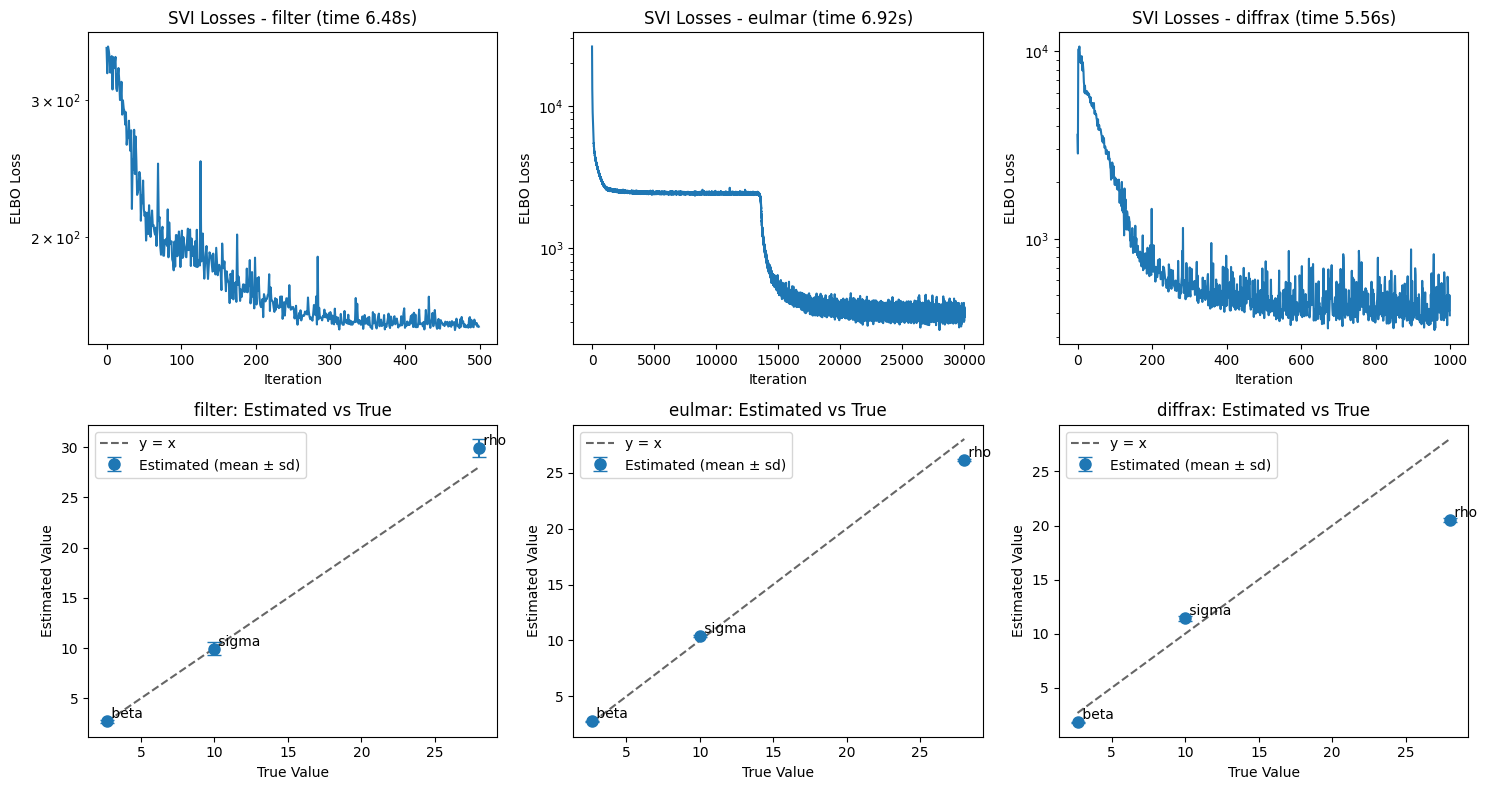

In [6]:
num_svi_steps_per_mode = {
    "filter": int(5e2),
    "eulmar": int(3e4),
    "diffrax": int(1e3)
}
learning_rate_per_mode = {
    "filter": 1e-2,
    "eulmar": 1e-1,
    "diffrax": 2e-2,
}

t_emissions = jnp.linspace(0.0, 2.0, 100).reshape(-1, 1)

results_short_traj_partialObs = {}
mode_list = ['filter', 'eulmar', 'diffrax']
for mode in mode_list:
    results_short_traj_partialObs[mode] = run_experiment(emission_dim=1,
                                   mode=mode,
                                   num_svi_steps=num_svi_steps_per_mode[mode],
                                   learning_rate=learning_rate_per_mode[mode],
                                   do_mcmc=False,
                                   t_emissions=t_emissions,
                                )
# Compare results
compare_runs(results_short_traj_partialObs)

## T=10, dt=0.02


 #### Running experiment in **filter** mode ####
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path
Filter's marginal neg_log_likelihood of data w/ true model: [735.77460722]
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


100%|██████████| 500/500 [00:07<00:00, 63.76it/s, init loss: 962.9521, avg. loss [476-500]: 743.0544]


Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path

SVI parameter summary:
  sigma: true=10.000, mean=10.537 ± 0.637, median=10.403
  rho: true=28.000, mean=28.968 ± 0.653, median=28.977
  beta: true=2.667, mean=2.698 ± 0.074, median=2.692
SVI took  11.282047986984253

 #### Running experiment in **eulmar** mode ####


100%|██████████| 15000/15000 [00:05<00:00, 2638.24it/s, init loss: 103815.8882, avg. loss [14251-15000]: 1653.8501]



SVI parameter summary:
  sigma: true=10.000, mean=10.604 ± 0.029, median=10.604
  rho: true=28.000, mean=25.819 ± 0.031, median=25.818
  beta: true=2.667, mean=2.951 ± 0.012, median=2.951
SVI took  7.577613115310669

 #### Running experiment in **diffrax** mode ####


100%|██████████| 1000/1000 [00:17<00:00, 58.17it/s, init loss: 23725.5432, avg. loss [951-1000]: 3904.1162]



SVI parameter summary:
  sigma: true=10.000, mean=2.152 ± 0.043, median=2.151
  rho: true=28.000, mean=11.002 ± 0.481, median=10.969
  beta: true=2.667, mean=2.635 ± 0.073, median=2.635
SVI took  23.331769943237305


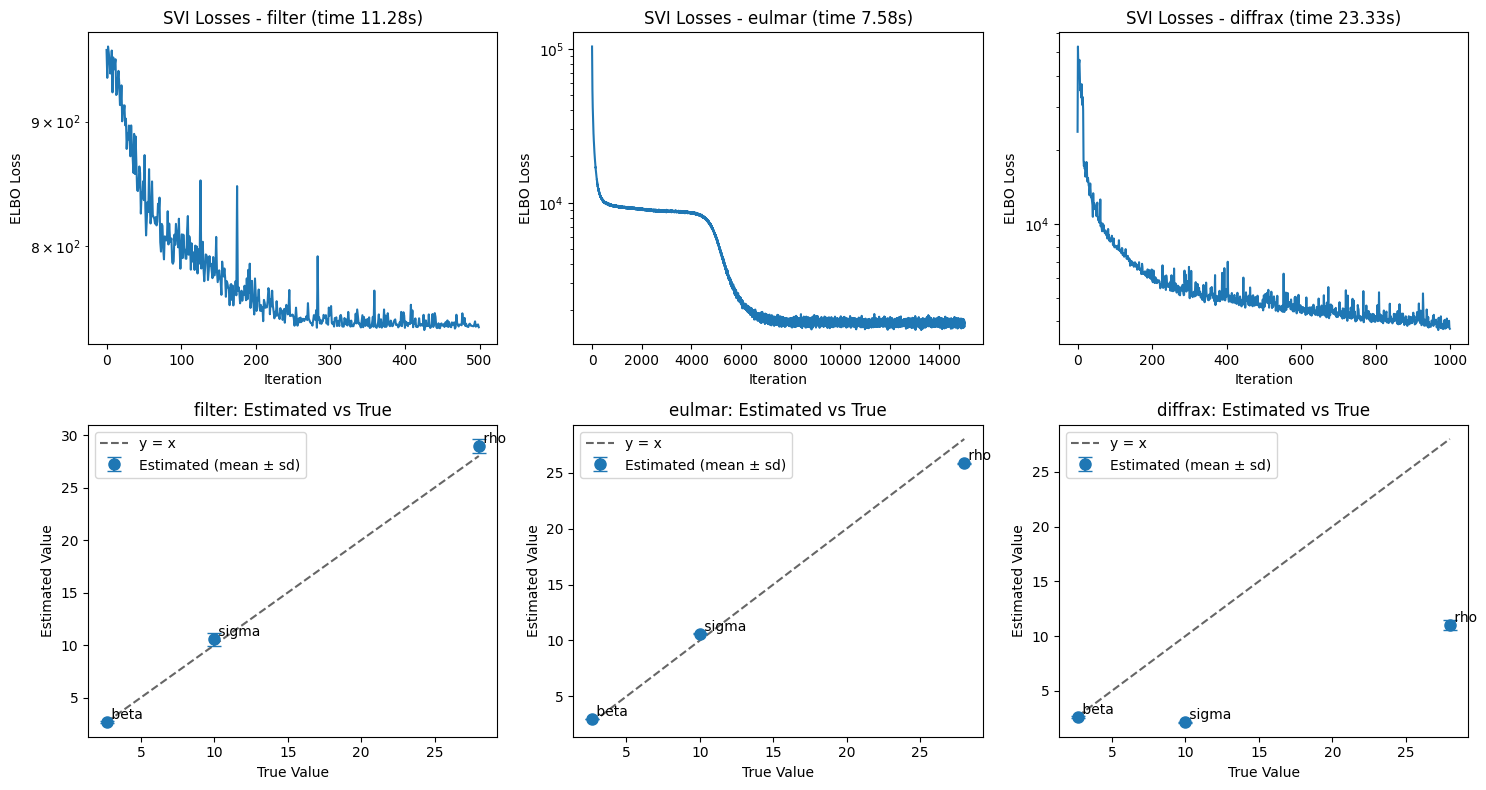

In [7]:
num_svi_steps_per_mode = {
    "filter": int(5e2),
    "eulmar": int(1.5e4),
    "diffrax": int(1e3)
}
learning_rate_per_mode = {
    "filter": 1e-2,
    "eulmar": 1e-1,
    "diffrax": 2e-2,
}

t_emissions = jnp.linspace(0.0, 10.0, 500).reshape(-1, 1)

results_med_traj_partialObs = {}
mode_list = ['filter', 'eulmar', 'diffrax']
for mode in mode_list:
    results_med_traj_partialObs[mode] = run_experiment(emission_dim=1,
                                   mode=mode,
                                   num_svi_steps=num_svi_steps_per_mode[mode],
                                   learning_rate=learning_rate_per_mode[mode],
                                   do_mcmc=False,
                                   t_emissions=t_emissions,
                                )
compare_runs(results_med_traj_partialObs)

## T=100, dt=0.02

In [ ]:
num_svi_steps_per_mode = {
    "filter": int(6e2),
    "eulmar": int(1.5e4),
    "diffrax": int(1e4)
}
learning_rate_per_mode = {
    "filter": 1e-2,
    "eulmar": 1e-1,
    "diffrax": 1e-2,
}

t_emissions = jnp.linspace(0.0, 100.0, 5000).reshape(-1, 1)

results_long_traj_partialObs = {}
mode_list = ['filter', 'eulmar'] #, 'diffrax']
for mode in mode_list:
    results_long_traj_partialObs[mode] = run_experiment(emission_dim=1,
                                   mode=mode,
                                   num_svi_steps=num_svi_steps_per_mode[mode],
                                   learning_rate=learning_rate_per_mode[mode],
                                   do_mcmc=False,
                                   t_emissions=t_emissions,
                                )
compare_runs(results_long_traj_partialObs)


 #### Running experiment in **filter** mode ####
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path
Filter's marginal neg_log_likelihood of data w/ true model: [10413.97408184]
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


 36%|███▌      | 216/600 [00:30<00:50,  7.59it/s, init loss: 13646.2893, avg. loss [181-210]: 10031.7440]

## T=1000

In [ ]:
num_svi_steps_per_mode = {
    "filter": int(5e2),
    "eulmar": int(1.5e4),
    "diffrax": int(1e3)
}
learning_rate_per_mode = {
    "filter": 1e-2,
    "eulmar": 1e-1,
    "diffrax": 2e-2,
}

t_emissions = jnp.linspace(0.0, 1000.0, 50000).reshape(-1, 1)

results = {}
mode_list = ['filter', 'eulmar'] #, 'diffrax']
for mode in mode_list:
    results[mode] = run_experiment(emission_dim=1,
                                   mode=mode,
                                   num_svi_steps=num_svi_steps_per_mode[mode],
                                   learning_rate=learning_rate_per_mode[mode],
                                   do_mcmc=False,
                                   t_emissions=t_emissions,
                                )
compare_runs(results)